# Final Keystone Project

### 5.1 Import Key Libraries and Datasets

In [1]:
import pandas as pd

In [2]:
JPM_df = pd.read_csv('JPM.csv')
JPM_df

,Date,Open,High,Low,Close,Adj Close,Volume
0,7/14/2017,90.809998,92.610001,90.580002,92.250000,79.338943,22235200
1,7/17/2017,91.820000,91.989998,91.250000,91.389999,78.599312,14374200
2,7/18/2017,90.449997,91.580002,90.320000,91.070000,78.324104,14719400
3,7/19/2017,91.339996,91.620003,91.000000,91.199997,78.435898,11651200
4,7/20/2017,91.150002,91.720001,90.900002,91.199997,78.435898,11561700
...,...,...,...,...,...,...,...
1363,12/12/2022,132.399994,134.649994,131.600006,134.210007,134.210007,8841600
1364,12/13/2022,136.889999,137.089996,133.080002,134.080002,134.080002,10025400
1365,12/14/2022,133.779999,135.710007,132.759995,133.410004,133.410004,9966100
1366,12/15/2022,131.149994,132.080002,129.050003,130.100006,130.100006,12087800


In [3]:
JPM_df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [4]:
JPM_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1368 entries, 0 to 1367
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1368 non-null   str    
 1   Open       1368 non-null   float64
 2   High       1368 non-null   float64
 3   Low        1368 non-null   float64
 4   Close      1368 non-null   float64
 5   Adj Close  1368 non-null   float64
 6   Volume     1368 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 74.9 KB


### 5.2 Calculate Percentage Daily Returns

In [5]:
JPM_df['Daily Returns'] = JPM_df['Adj Close'].pct_change(1)*100
JPM_df

,Date,Open,High,Low,Close,Adj Close,Volume,Daily Returns
0,7/14/2017,90.809998,92.610001,90.580002,92.250000,79.338943,22235200,NaN
1,7/17/2017,91.820000,91.989998,91.250000,91.389999,78.599312,14374200,-0.932243
2,7/18/2017,90.449997,91.580002,90.320000,91.070000,78.324104,14719400,-0.350140
3,7/19/2017,91.339996,91.620003,91.000000,91.199997,78.435898,11651200,0.142732
4,7/20/2017,91.150002,91.720001,90.900002,91.199997,78.435898,11561700,0.000000
...,...,...,...,...,...,...,...,...
1363,12/12/2022,132.399994,134.649994,131.600006,134.210007,134.210007,8841600,1.551152
1364,12/13/2022,136.889999,137.089996,133.080002,134.080002,134.080002,10025400,-0.096867
1365,12/14/2022,133.779999,135.710007,132.759995,133.410004,133.410004,9966100,-0.499700
1366,12/15/2022,131.149994,132.080002,129.050003,130.100006,130.100006,12087800,-2.481072


In [6]:
JPM_df['Daily Returns'].max()

np.float64(18.012495662164163)

### 5.3 Data Visulaisation for Single Stock pt1

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns


JPM_df['Date'] = pd.to_datetime(JPM_df['Date'])

print("Pandas:", pd.__version__)

Pandas: 3.0.5


In [36]:
def plot_financial_data(df, title):
    
    plt.figure(figsize=(14, 6))

    for col in df.columns:
        if col != 'Date':
            plt.plot(
                df['Date'],
                df[col],
                label=col,
                linewidth=1
            )

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Price [$]')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

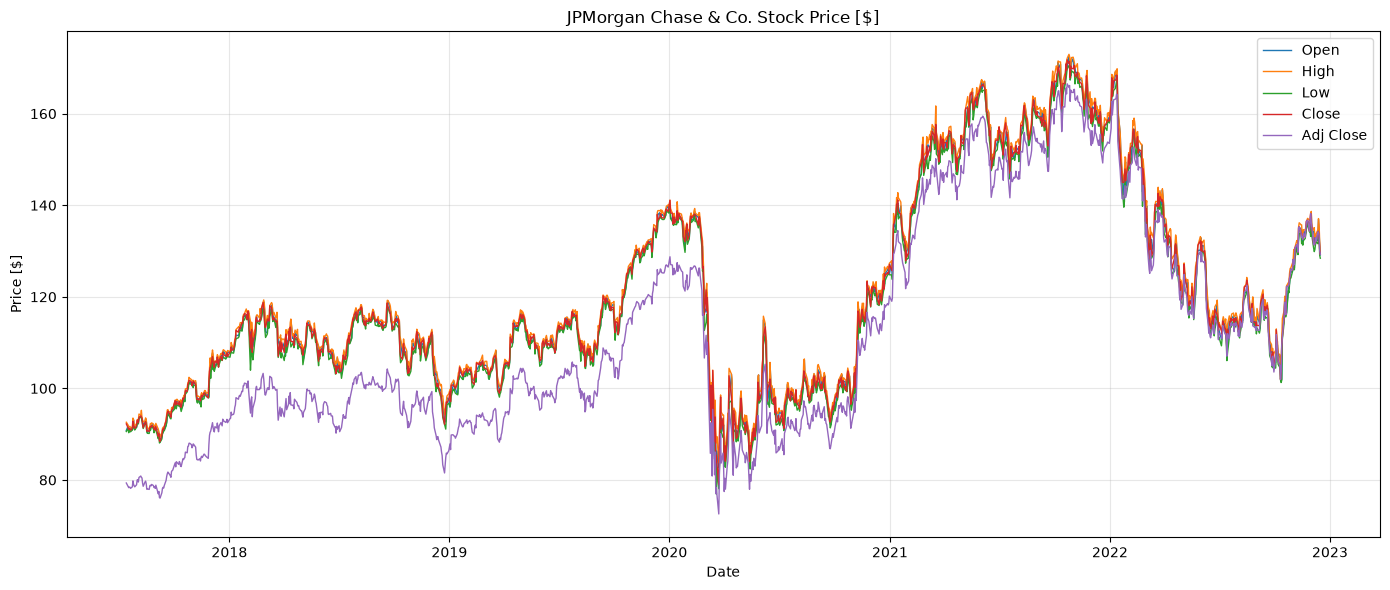

In [37]:
plot_financial_data(
    JPM_df.drop(['Volume', 'Daily Returns'], axis=1),
    'JPMorgan Chase & Co. Stock Price [$]'
)

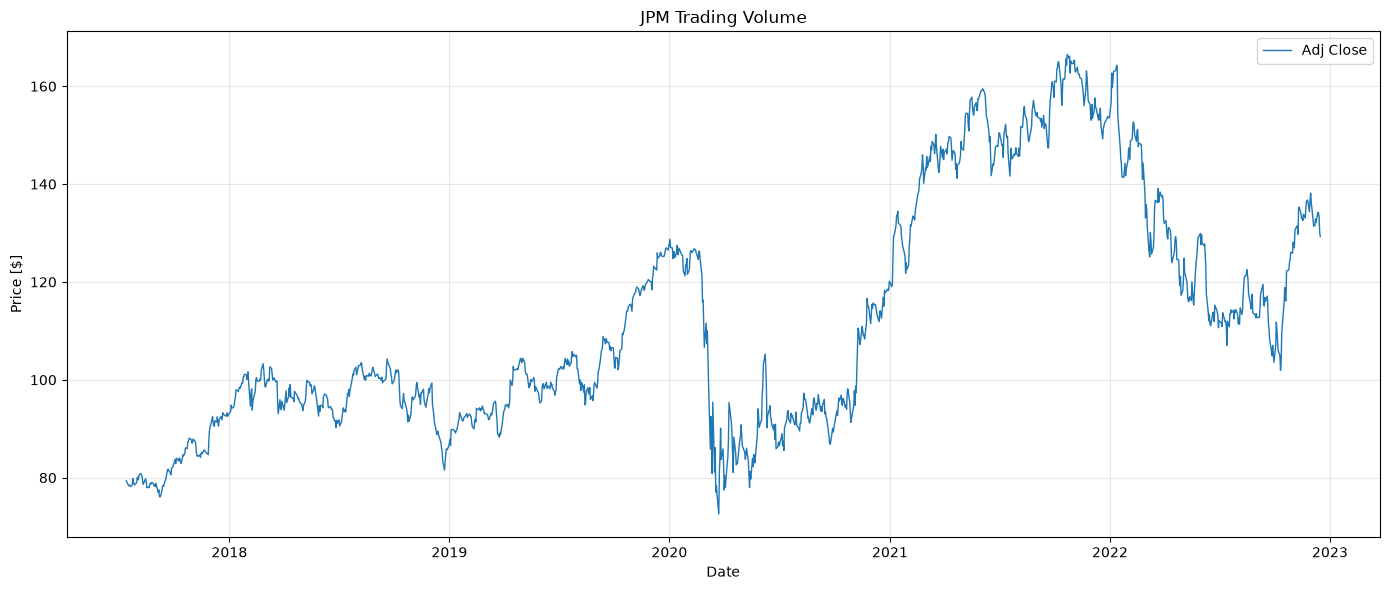

In [38]:
plot_financial_data(JPM_df.iloc[:,[0,5]], 'JPM Trading Volume')

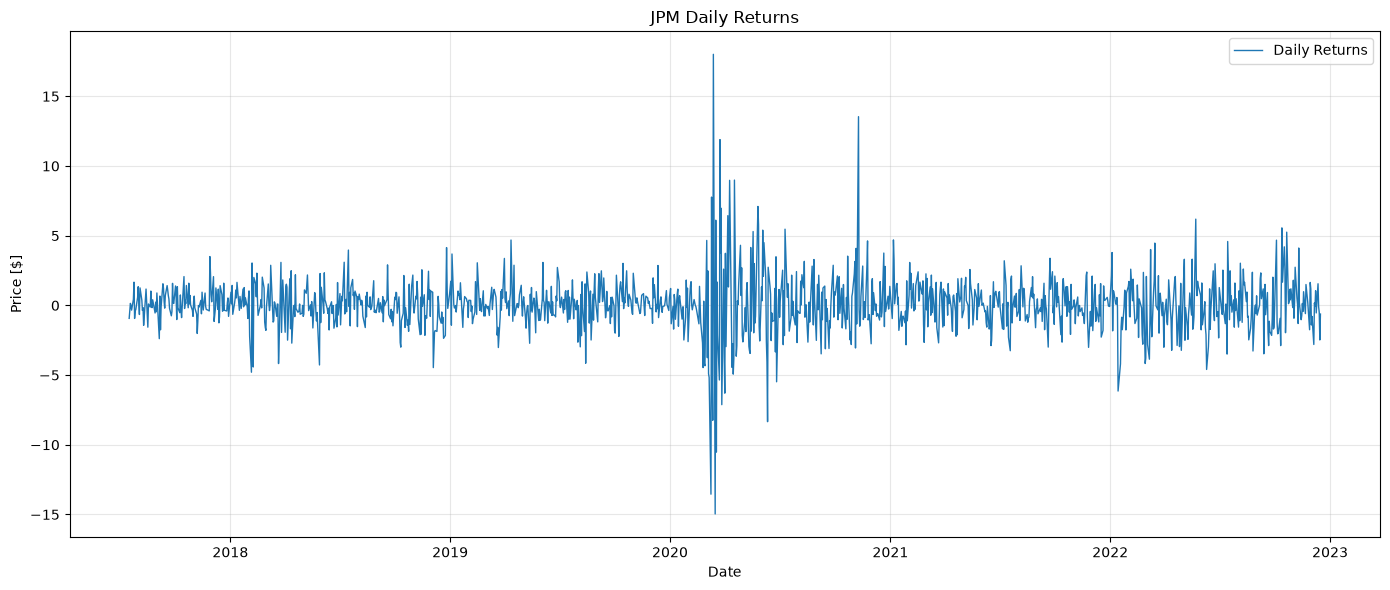

In [39]:
plot_financial_data(JPM_df.iloc[:, [0,7]], 'JPM Daily Returns')